Upload Mall_Customers.csv


Saving Mall_Customers.csv to Mall_Customers (1).csv

========== FIRST 5 ROWS ==========
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

========== DATASET SHAPE ==========
(200, 5)

========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null  

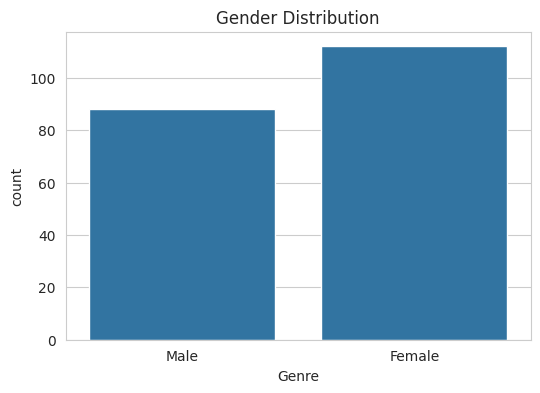

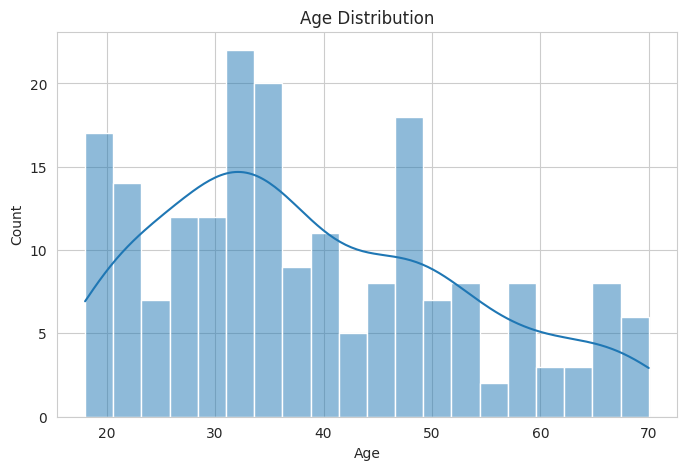

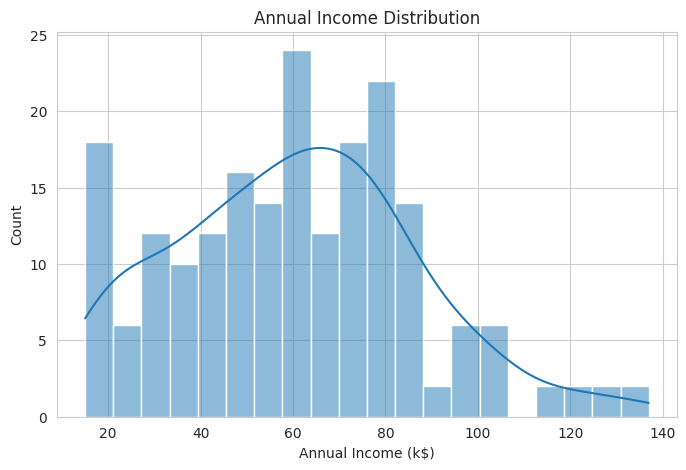

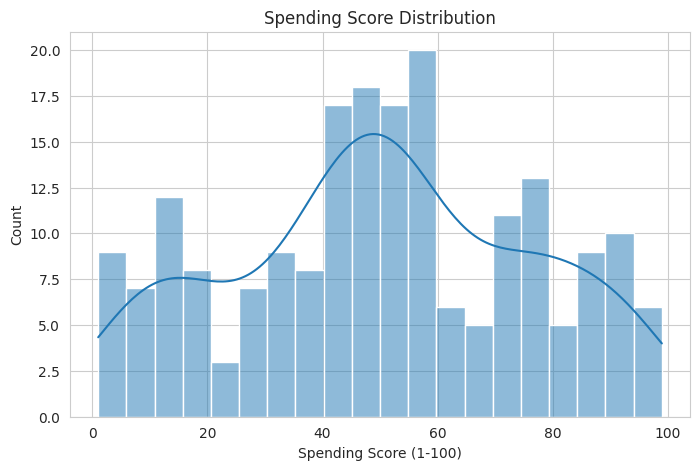

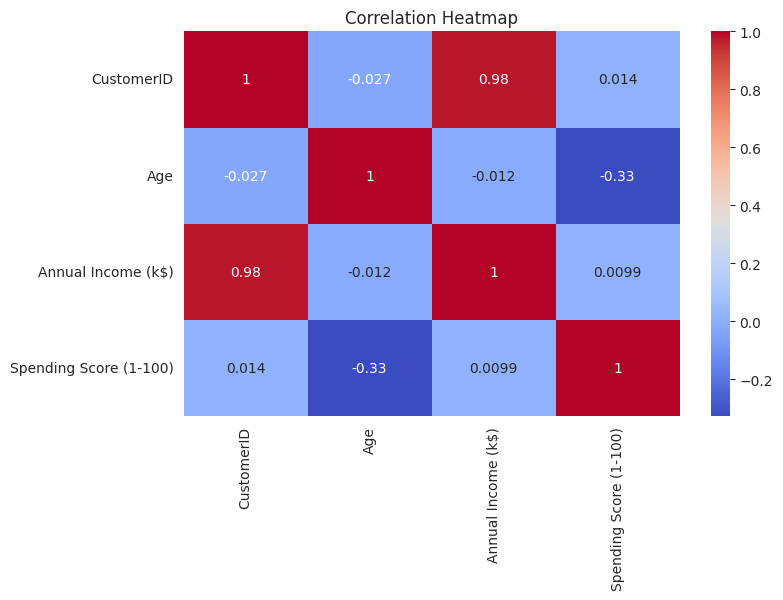

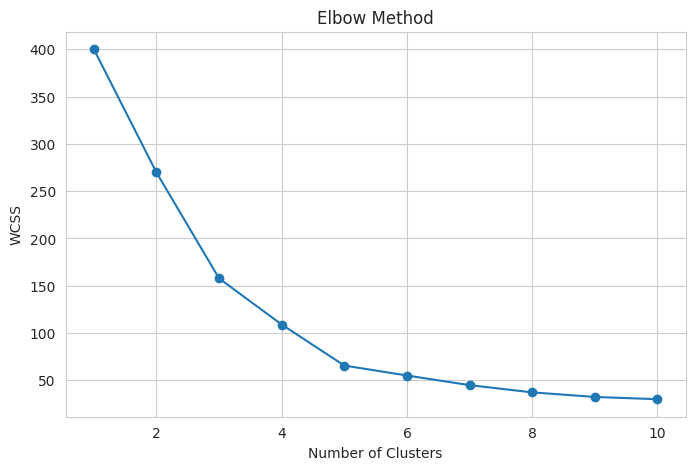


========== CLUSTER COUNTS ==========
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


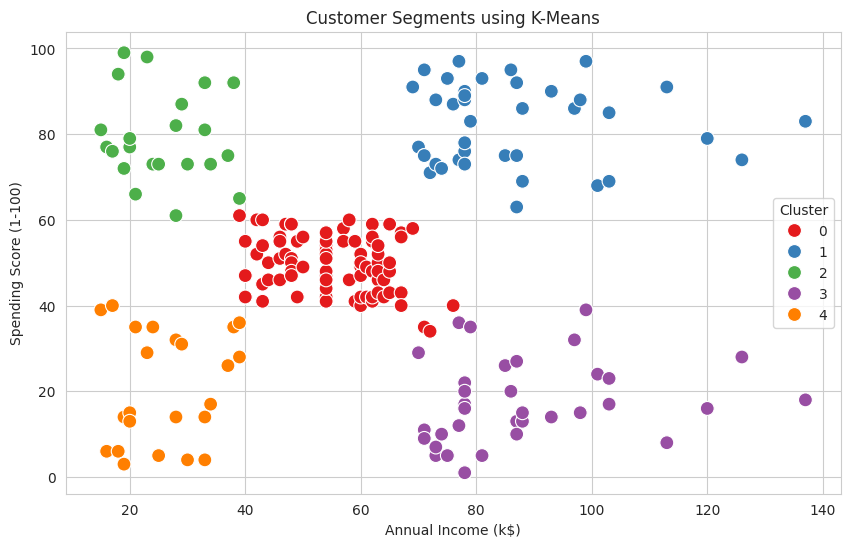

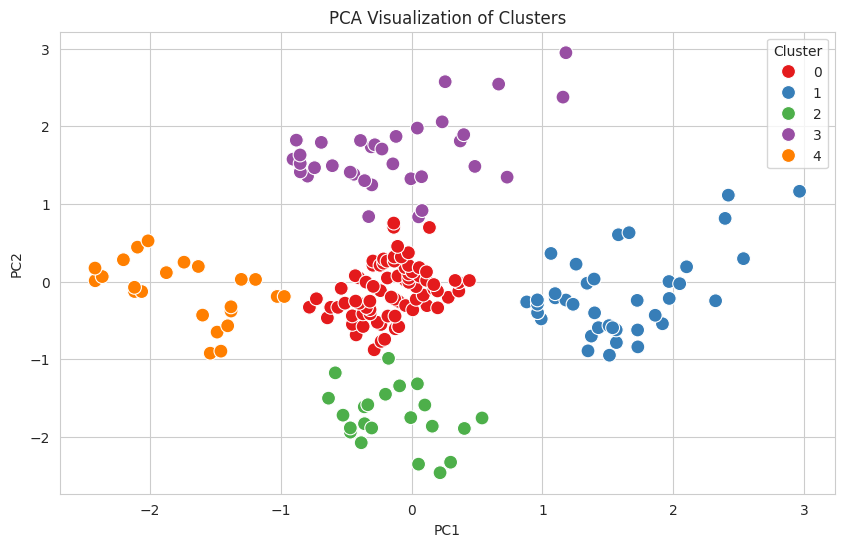


========== CLUSTER SUMMARY ==========
         Annual Income (k$)  Spending Score (1-100)        Age
Cluster                                                       
0                 55.296296               49.518519  42.716049
1                 86.538462               82.128205  32.692308
2                 25.727273               79.363636  25.272727
3                 88.200000               17.114286  41.114286
4                 26.304348               20.913043  45.217391

========== MARKETING STRATEGIES ==========


Cluster 0:
High Income - High Spending
Strategy:
- VIP Membership Programs
- Premium Product Launches
- Personalized Services

Cluster 1:
High Income - Low Spending
Strategy:
- Upselling Campaigns
- Exclusive Promotions
- Personalized Recommendations

Cluster 2:
Low Income - High Spending
Strategy:
- Loyalty Programs
- Seasonal Discounts
- Reward-Based Marketing

Cluster 3:
Low Income - Low Spending
Strategy:
- Budget-Friendly Offers
- Discount Campaigns
- Entry-Level P

In [4]:
# ==========================================================
# TASK 2: CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
# DevelopersHub Data Science Internship
# ==========================================================

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from google.colab import files

sns.set_style("whitegrid")

# ==========================================================
# UPLOAD DATASET
# ==========================================================

print("Upload Mall_Customers.csv")

uploaded = files.upload()

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("Mall_Customers.csv")

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== DATA INFO ==========")
print(df.info())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# ==========================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

# Gender Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Genre", data=df)
plt.title("Gender Distribution")
plt.show()

# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Income Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

# Spending Score Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

# Correlation Heatmap

plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# SELECT FEATURES FOR CLUSTERING
# ==========================================================

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================================
# ELBOW METHOD
# ==========================================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# ==========================================================
# K-MEANS CLUSTERING
# ==========================================================

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("\n========== CLUSTER COUNTS ==========")
print(df["Cluster"].value_counts())

# ==========================================================
# CLUSTER VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segments using K-Means")

plt.show()

# ==========================================================
# PCA VISUALIZATION
# ==========================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("PCA Visualization of Clusters")

plt.show()

# ==========================================================
# CLUSTER ANALYSIS
# ==========================================================

cluster_summary = df.groupby("Cluster")[[
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Age"
]].mean()

print("\n========== CLUSTER SUMMARY ==========")
print(cluster_summary)

# ==========================================================
# MARKETING STRATEGIES
# ==========================================================

print("\n========== MARKETING STRATEGIES ==========")

print("""

Cluster 0:
High Income - High Spending
Strategy:
- VIP Membership Programs
- Premium Product Launches
- Personalized Services

Cluster 1:
High Income - Low Spending
Strategy:
- Upselling Campaigns
- Exclusive Promotions
- Personalized Recommendations

Cluster 2:
Low Income - High Spending
Strategy:
- Loyalty Programs
- Seasonal Discounts
- Reward-Based Marketing

Cluster 3:
Low Income - Low Spending
Strategy:
- Budget-Friendly Offers
- Discount Campaigns
- Entry-Level Products

Cluster 4:
Average Customers
Strategy:
- Customer Retention Programs
- Cross-Selling Opportunities
- Regular Engagement Campaigns

""")

# ==========================================================
# FINAL CONCLUSION
# ==========================================================

print("\n========== CONCLUSION ==========")

print("""
K-Means clustering successfully segmented customers
into distinct groups based on annual income and spending
behavior.

The identified segments can help businesses design
targeted marketing strategies, improve customer
engagement and increase revenue through personalized
campaigns.

PCA visualization confirmed clear separation among
customer groups, demonstrating the effectiveness of
customer segmentation using unsupervised learning.
""")